## | 專案概述

本研究以 IZ*ONE 直拍資料為研究對象，探討影響直拍觀看數的關鍵因素

透過資料清理、EDA、特徵工程、迴歸模型與統計驗證，建立觀看數預測模型，並分析各舞台特徵對觀看數的影響

本研究亦作為後續 LLM 留言分析與 AI Agent 建構的基礎

dataset overview

In [ ]:
import pandas as pd
from google.colab import drive
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/colabnotebooks/dataset.csv")
df.info()
df.shape
df.head()

Data Cleaning

In [ ]:
df = df.iloc[:, 1:]
df.columns = [
    "song","member","line_share","post_week",
    "opening","ending_take","center_count",
    "comment_text","views"
]

df["line_share"] = df["line_share"].str.replace("%","").astype(float)
df["views"] = df["views"].str.replace(",","").astype(int)
df["log_views"] = np.log(df["views"]).round(3)
df["opening"] = 1 - df["opening"]
df["ending_take"] = 1 - df["ending_take"]

df = df.dropna()
df.info()
df.head(5)

In [ ]:
df.describe()

**｜EDA**

了解觀看數分布、各變數間關聯、離群值與初步趨勢(散布、共線)，驗證原始假說 ; 作為特徵工程與模型建立的依據

｜特徵工程（leaveoneout encoder)

另新變數popularity(log_views(mean))，採留一平均法消除數據洩漏



In [ ]:
sorted = df.groupby("member")["views"].mean().sort_values(ascending=False).reset_index()
sorted["views"] = sorted["views"].round(2)
print(sorted)

      member      views
0    sakura   863791.13
1      minju  732488.57
2    chaewon  688552.87
3   wonyoung  620793.06
4   chaeyeon  599682.71
5     hitomi  467157.00
6     hyewon  454899.13
7       yena  429441.69
8       yuri  375596.69
9      eunbi  354022.21
10      nako  328299.33
11     yujin  280067.07


In [ ]:
df.groupby(["opening","ending_take"])["log_views"].mean()

opening  ending_take
0.0      0.0            12.480246
         1.0            13.024679
1.0      0.0            11.962286
         1.0            13.501300
Name: log_views, dtype: float64

In [ ]:
Q1 = df["log_views"].quantile(0.25)
Q3 = df["log_views"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["log_views"] < lower) | (df["log_views"] > upper)]
outliers

In [ ]:
!pip install category_encoders
from category_encoders import LeaveOneOutEncoder

loo_encoder = LeaveOneOutEncoder(cols=['member'])
df['popularity'] = loo_encoder.fit_transform(df['member'], df['log_views'])

print(df[['member', 'log_views', 'popularity']].head(20))

member_avg = df.groupby("member")["log_views"].mean()
df["popularity"] = df.groupby("member")["log_views"].transform(lambda x: x.mean())
print(df.groupby("member")["popularity"].mean().sort_values(ascending=False))

In [ ]:
df.to_excel("data_cleaning.xlsx",index=False)

In [ ]:
print(df[["line_share","post_week","opening","center_count","ending_take","popularity","log_views"]].corr())

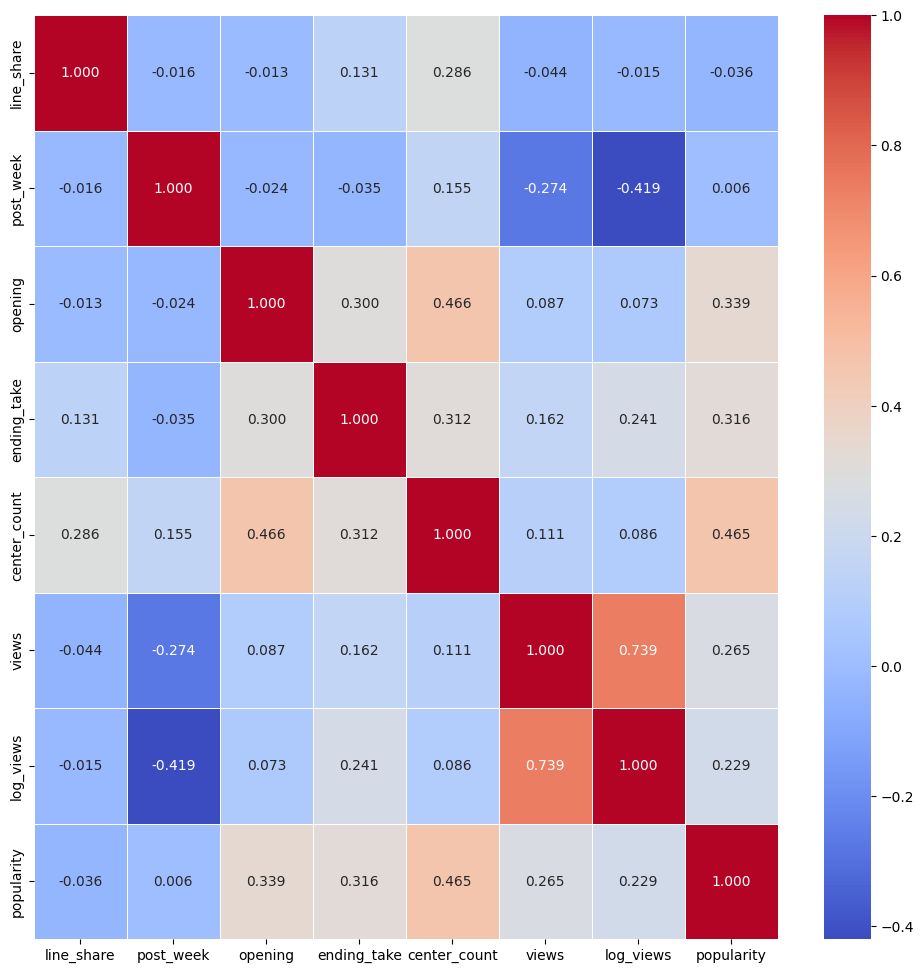

In [ ]:
plt.figure(figsize=(12, 12))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)
plt.show()

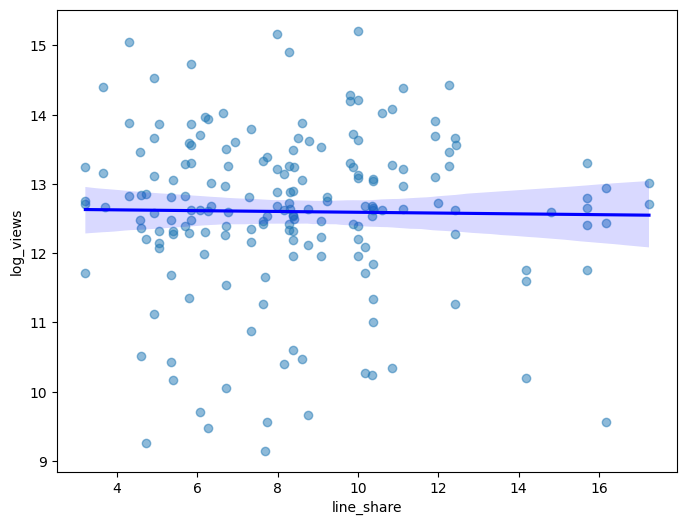

In [ ]:
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x="line_share", y="log_views",
            scatter_kws={'alpha':0.5}, line_kws={'color':'blue'})
plt.xlabel("line_share")
plt.ylabel("log_views")
plt.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_temp = df[[
    "line_share",
    "center_count",
]]

vif_data = pd.DataFrame()
vif_data["Variable"] = X_temp.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_temp.values, i)
    for i in range(X_temp.shape[1])
]

print(vif_data)

       Variable       VIF
0    line_share  6.139794
1  center_count  6.139794


In [ ]:
plt.hist(df["views"], bins=28)
plt.title("Views Distribution")
plt.xlabel("Views")
plt.ylabel("Frequency")
plt.show()


plt.boxplot(df["views"])
plt.title("Views Boxplot")
plt.ylabel("Views")
plt.show()

**| Modeling**

- 建立迴歸模型  Multiple Regression ➡
- 控制歌曲固定效果  Song Fixed Effect ➡
- 模型最佳化  Stepwise( R-square 0.48 ) + Ridge ➡
- 模型驗證  K-Fold Cross Validation( 平均 R-square 0.33 ) + feature importance

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

X = pd.get_dummies(df[[
    "line_share",
    "post_week",
    "opening",
    "center_count",
    "ending_take",
    "popularity",
    "song"]], drop_first=True)

y = df["log_views"]

lr = LinearRegression()
lr.fit(X, y)

# 將係數與對應的欄位名稱配對
features = X.columns
coefficients = lr.coef_

print(f"截距 (Beta 0): {lr.intercept_:.4f}")
print("-" * 30)
for name, coef in zip(features, coefficients):
    print(f"{name:15} : {coef:8.4f}")

截距 (Beta 0): 3.9703
------------------------------
line_share      :  -0.0212
post_week       :  -0.8376
opening         :  -0.3277
center_count    :   0.0171
ending_take     :   0.6284
popularity      :   0.7498
song_La Vei En Rose :   0.0711
song_Panorama   :   0.2758
song_Secret Story of the Swan :  -1.0045
song_Violeta    :  -0.9524


In [ ]:
# 期中
X = pd.get_dummies(df[[
    "member", "line_share", "post_week",
    "opening", "center_count", "ending_take"
]], drop_first=True)

y = df["log_views"]

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X, y)

coef_summary = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values(by='Coefficient', ascending=False)

print(coef_summary)

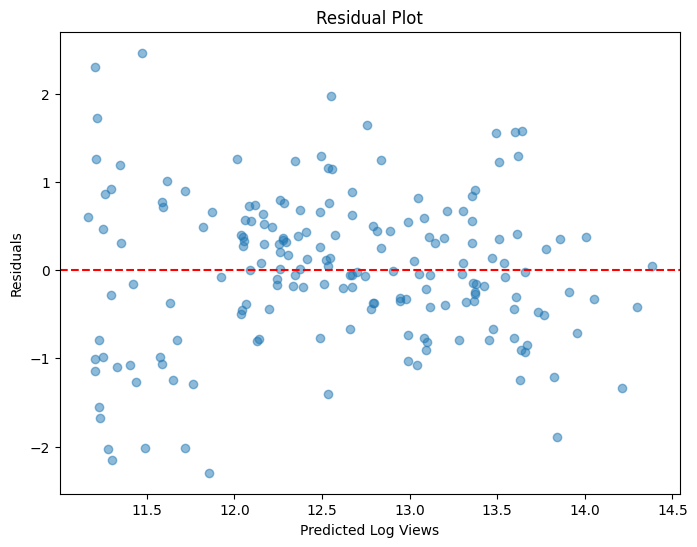

R-squared: 0.47425713464503316


In [ ]:
residual = y - lr.predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(lr.predict(X), residual, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Log Views")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

from sklearn.metrics import r2_score

r2 = r2_score(y, lr.predict(X))
print("R-squared:", r2)

In [ ]:
#stepwise model
models = [
    ["popularity"],
    ["popularity", "line_share"],
    ["popularity", "line_share", "center_count"],
    ["popularity", "line_share", "center_count", "opening"],
    ["popularity", "line_share", "center_count", "opening", "ending_take"],
    ["popularity", "line_share", "center_count", "opening", "ending_take", "post_week"]
]

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

results = []

for features in models:
    X_temp = pd.get_dummies(df[features + ["song"]], drop_first=True)

    lr = LinearRegression()
    lr.fit(X_temp, y)

    y_pred = lr.predict(X_temp)
    r2 = r2_score(y, y_pred)

    results.append({
        "Model": "+".join(features),
        "R2": round(r2, 4)
    })

import pandas as pd
pd.DataFrame(results)

,Model,R2
0,popularity,0.3127
1,popularity+line_share,0.3129
2,popularity+line_share+center_count,0.3168
3,popularity+line_share+center_count+opening,0.3168
4,popularity+line_share+center_count+opening+end...,0.3631
5,popularity+line_share+center_count+opening+end...,0.4743


In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Ridge

kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = Ridge(alpha=10)
scores = cross_val_score(model, X, y, cv=kf, scoring="r2")

print(f"R2: {scores}")
print(f"平均R2: {np.mean(scores):.4f}")

R2: [ 0.49810803  0.37288743 -0.01744173  0.38003552  0.40993718]
平均R2: 0.3287


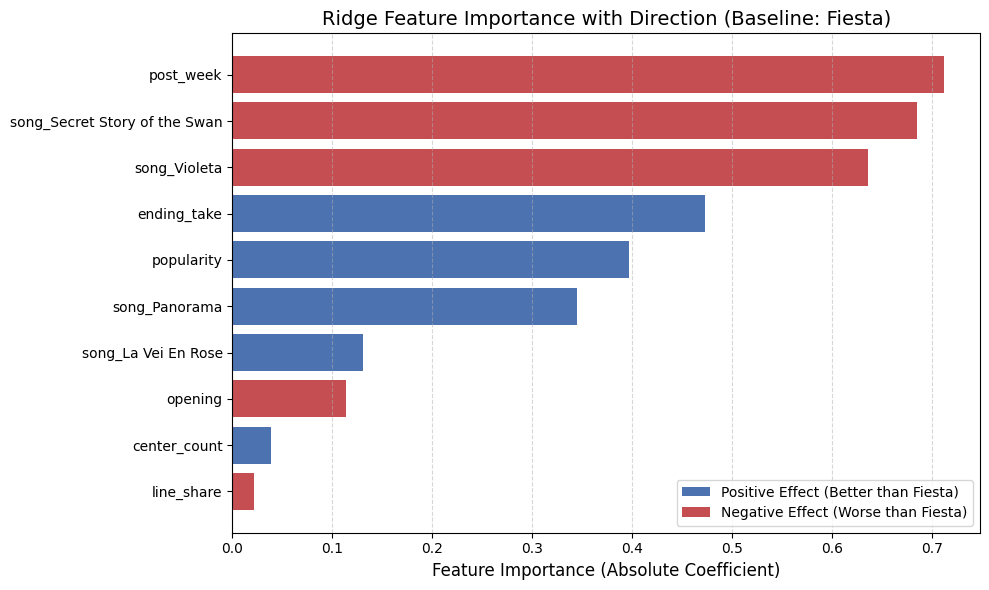

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

final_model = Ridge(alpha=10)
final_model.fit(X, y)
df_importance = pd.DataFrame(
    {
        "Feature": X.columns,
        "Coefficient": final_model.coef_,  # 原始係數（有正負）
        "Importance": np.abs(final_model.coef_),  # 絕對值（影響力大小）
    }
)

df_importance["Direction"] = np.where(
    df_importance["Coefficient"] > 0, "Positive (+)", "Negative (-)"
)
df_importance = df_importance.sort_values(by="Importance", ascending=True)
plt.figure(figsize=(10, 6))

colors = df_importance["Direction"].map(
    {"Positive (+)": "#4C72B0", "Negative (-)": "#C44E52"}
)
bars = plt.barh(
    df_importance["Feature"], df_importance["Importance"], color=colors
)

plt.xlabel("Feature Importance (Absolute Coefficient)", fontsize=12)
plt.title(
    "Ridge Feature Importance with Direction (Baseline: Fiesta)", fontsize=14
)
plt.grid(axis="x", linestyle="--", alpha=0.5)

# 建立手動圖例
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="#4C72B0", label="Positive Effect (Better than Fiesta)"),
    Patch(facecolor="#C44E52", label="Negative Effect (Worse than Fiesta)"),
]
plt.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.show()

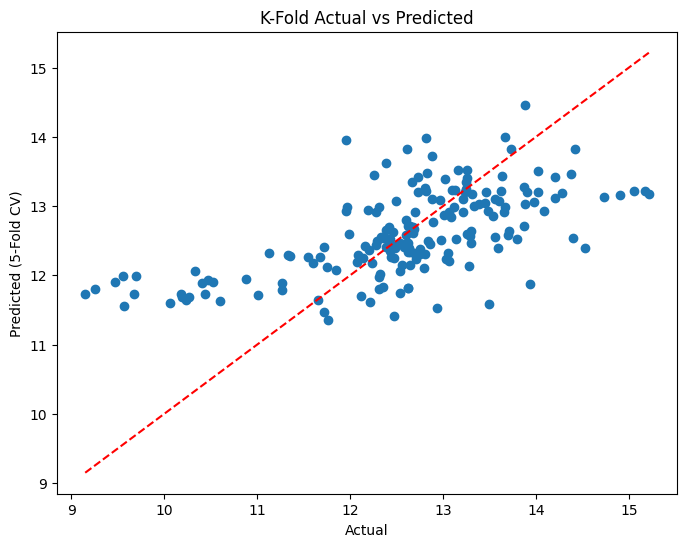

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import Ridge

# Re-initialize the model as a scikit-learn estimator (Ridge)
model = Ridge(alpha=10)

y_cv_pred = cross_val_predict(model, X, y, cv=kf, method="predict")

plt.figure(figsize=(8, 6))
plt.scatter(y, y_cv_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')

plt.xlabel('Actual')
plt.ylabel('Predicted (5-Fold CV)')
plt.title('K-Fold Actual vs Predicted')
plt.show()

In [ ]:
#期中/純切資料、訓練集
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_regression(y_true, y_pred, X_data):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    n = len(y_true)
    p = X_data.shape[1]
    adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    return mse, rmse, mae, r2, adjusted_r2

train_metrics = evaluate_regression(y_train, y_pred_train, X_train)
test_metrics = evaluate_regression(y_test, y_pred_test, X_test)
metric_names = ["MSE", "RMSE", "MAE", "R²", "Adjusted R²"]

print("=== Training Performance ===")
for name, value in zip(metric_names, train_metrics):
    print(f"{name}: {value:.4f}")

print("\n=== Testing Performance ===")
for name, value in zip(metric_names, test_metrics):
    print(f"{name}: {value:.4f}")

plt.scatter(y_test, y_pred_test)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("comparsion")
plt.show()

In [ ]:
import statsmodels.formula.api as smf

# 最小平方
model = smf.ols(
    formula="""
    log_views ~
    popularity +
    line_share +
    center_count +
    opening +
    ending_take +
    post_week +
    C(song)
    """,
    data=df
).fit()

print(model.summary())

## 研究發現

* 分析結果指出，**Ending Take（結尾中心鏡頭）** 為影響直拍觀看數的重要舞台特徵，其解釋力高於原先預期的center count / line share，舞台的最後特寫鏡頭更可能影響觀眾觀看意願及反應流量表現
* 歌曲本身熱度與回歸週期仍為影響觀看數的重要因素，為外部環境共同影響

然而，仍存在部分觀看數變異無法由結構化特徵解釋，因此推測留言內容可能蘊含額外的語意資訊

下一階段將導入大型語言模型分析留言，探討粉絲討論內容是否能補足統計模型的解釋能力